In [1]:
import numpy
print(numpy.__file__)
import pandas as pd
import torch
import torch.nn as nn
import sys
import os

from AIedes.models.counter_models import (
    PositiveFeedForwardAbundanceModel,
    PositiveLSTMAbundanceModel,
    PositiveMultiHeadAttentionModel,
    PositiveHurdleModel
)
from AIedes.train.counter_train import train_mosquito_net

from AIedes.data_loader.counter_data_loader import (
    load_and_process_data,
    prepare_data,
)

from AIedes.utils.counter_losses import get_criterion



/home/biazzin/conda-envs/aiedes-env/lib/python3.12/site-packages/numpy/__init__.py


In [3]:
random_state = 3
dropout_rate = 0.2
layers = 2
hidden_size = 64
bs = 64
learning_rate = "5e-05"  # From your data (appears to be consistent)

input_variables = "t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn"
name_file = "modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd14_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn"

path = "../../data/"
df = pd.read_pickle(path + name_file + "_results.pkl")
model = torch.load(path+name_file + ".pth", map_location=torch.device('cpu'), weights_only=False)

In [4]:

from sklearn.model_selection import train_test_split
import  numpy as np

params = {
    "model_type": df["model_type"][0],  # or any of the allowed models
    "hidden_dim": df["hidden_dim"][0],
    "num_layers": df["num_layers"][0],
    "dropout": df["dropout"][0],
    "num_epochs": df["num_epochs"][0],
    "lr": df["learning_rate"][0],
    "batch_size": int(df["batch_size"][0]),
    "random_state": int(df["random_state"][0]),
    "num_threads": 1,
    #"variables": ["t2m:mean,max:30", "tp:mean,max:30"],
    #"variables":   "t2m_mean_znorm tp_sum_znorm d2m_mean_znorm p1zn p2zn".split(),
    #"variables":   "t2m_mean_znorm tp_sum_znorm p1zn p2zn".split(),
    "variables":   "t2m_mean_znorm d2m_mean_znorm tp_sum_znorm p1zn p2zn".split(),
    "loss_type": df["loss_type"][0],  # or another from the list
    # "nonzero_weight": 3.0,  # Uncomment if used
    "num_heads": 4,
    "folder_res": "./results/",
    "device": "cpu",  # or "cpu"
    "input_file": "../../data/eggs_y_norm_7days.pkl",
    "save_loss_fig": "yes",  # or "no"
    "plot_loss": False,
    "save_interval": 10,
    "bins": [1],  # Or [0, 10, 50, 200] if you want bins
}

climate_tensor, targets, class_labels, variable_info = load_and_process_data(params)

all_idx = np.arange(len(climate_tensor))
train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=params["random_state"],
    stratify=class_labels if class_labels is not None else None,
)

# And later:
data_egg = pd.read_pickle(params["input_file"])  # Or however you got your original dataframe

# To recover rows:
split_status = np.full(len(all_idx), "", dtype=object)
split_status[train_idx] = "train"
split_status[test_idx] = "test"
data_egg["split"] = split_status
# If climate_tensor and targets are numpy arrays, convert each row to torch.tensor
data_egg["input_data"] = [torch.tensor(x, dtype=torch.float32) for x in climate_tensor]
data_egg["target_data"] = [np.array(x, dtype=np.float32)[0] for x in targets]


Normalizing data...
Normalized 34 fields: ['tp_sum', 'u10_min', 'u10_max', 'u10_mean', 'v10_min', 'v10_max', 'v10_mean', 'd2m_min', 'd2m_max', 'd2m_mean', 't2m_min', 't2m_max', 't2m_mean', 'swvl1_min', 'swvl1_max', 'swvl1_mean', 'tp_sum_monthly', 'u10_min_monthly', 'u10_max_monthly', 'u10_mean_monthly', 'v10_min_monthly', 'v10_max_monthly', 'v10_mean_monthly', 'd2m_min_monthly', 'd2m_max_monthly', 'd2m_mean_monthly', 't2m_min_monthly', 't2m_max_monthly', 't2m_mean_monthly', 'swvl1_min_monthly', 'swvl1_max_monthly', 'swvl1_mean_monthly', 'prev1_rates', 'prev2_rates']


In [5]:

params_vectorNet = {
    "model_type": df["model_type"][0],  # or any of the allowed models
    "hidden_dim": df["hidden_dim"][0],
    "num_layers": df["num_layers"][0],
    "dropout": df["dropout"][0],
    "num_epochs": df["num_epochs"][0],
    "lr": df["learning_rate"][0],
    "batch_size": int(df["batch_size"][0]),
    "random_state": int(df["random_state"][0]),
    "num_threads": 1,
    #"variables": ["t2m:mean,max:30", "tp:mean,max:30"],
    #"variables":   "t2m_mean_znorm tp_sum_znorm d2m_mean_znorm p1zn p2zn".split(),
    #"variables":   "t2m_mean_znorm tp_sum_znorm p1zn p2zn".split(),
    "variables":   "t2m_mean_znorm d2m_mean_znorm tp_sum_znorm p1zn p2zn".split(),
    "loss_type": df["loss_type"][0],  # or another from the list
    # "nonzero_weight": 3.0,  # Uncomment if used
    "num_heads": 4,
    "folder_res": "./results/",
    "device": "cpu",  # or "cpu"
    "input_file": "../../data/eggs_y_norm_7days_vectorNet.pkl",
    "save_loss_fig": "yes",  # or "no"
    "plot_loss": False,
    "save_interval": 10,
    "bins": [1],  # Or [0, 10, 50, 200] if you want bins
}

climate_tensor_vectorNet, targets_vectorNet, class_labels_vectorNet, variable_info_vectorNet = load_and_process_data(params_vectorNet)
all_idx_vectorNet = np.arange(len(climate_tensor_vectorNet))
train_idx_vectorNet, test_idx_vectorNet = train_test_split(
    all_idx_vectorNet,
    test_size=0.2,
    random_state=params_vectorNet["random_state"],
    stratify=class_labels_vectorNet if class_labels_vectorNet is not None else None,
)
data_egg_vectorNet = pd.read_pickle(params_vectorNet["input_file"])  # Or however you got your original dataframe
# To recover rows:
split_status_vectorNet = np.full(len(all_idx_vectorNet), "", dtype=object)
split_status_vectorNet[train_idx_vectorNet] = "train"
split_status_vectorNet[test_idx_vectorNet] = "test"
data_egg_vectorNet["split"] = split_status_vectorNet
# If climate_tensor and targets are numpy arrays, convert each row to torch.tensor
data_egg_vectorNet["input_data"] = [torch.tensor(x, dtype=torch.float32) for x in climate_tensor_vectorNet]
data_egg_vectorNet["target_data"] = [np.array(x, dtype=np.float32)[0] for x in targets_vectorNet]


Normalizing data...
Normalized 16 fields: ['tp_sum', 'd2m_min', 'd2m_max', 'd2m_mean', 't2m_min', 't2m_max', 't2m_mean', 'tp_sum_monthly', 'd2m_min_monthly', 'd2m_max_monthly', 'd2m_mean_monthly', 't2m_min_monthly', 't2m_max_monthly', 't2m_mean_monthly', 'prev1_rates', 'prev2_rates']
Skipped 18 fields: ['u10_min (missing)', 'u10_max (missing)', 'u10_mean (missing)', 'v10_min (missing)', 'v10_max (missing)', 'v10_mean (missing)', 'swvl1_min (missing)', 'swvl1_max (missing)', 'swvl1_mean (missing)', 'u10_min_monthly (missing)', 'u10_max_monthly (missing)', 'u10_mean_monthly (missing)', 'v10_min_monthly (missing)', 'v10_max_monthly (missing)', 'v10_mean_monthly (missing)', 'swvl1_min_monthly (missing)', 'swvl1_max_monthly (missing)', 'swvl1_mean_monthly (missing)']


In [6]:
data_egg_vectorNet

,id_trap,start_date,end_date,verbatimScientificName,countryCode,occurrenceStatus,individualCount,decimalLatitude,decimalLongitude,trapLoc,...,t2m_mean_monthly_norm,prev_weeklyRates_norm,prev2_weeklyRates_norm,prev1_rates,prev2_rates,prev1_rates_norm,prev2_rates_norm,split,input_data,target_data
0,2020.333333,2021-05-31,2021-06-07,Aedes albopictus,IT,PRESENT,53.00,41.801041,12.600320,41.798956-12.604594,...,"[0.46050702695555296, 0.5077973790692458, 0.59...","[0, 0]","[0, 0]",NaN,NaN,NaN,NaN,test,"[tensor(-1.2019), tensor(-1.3364), tensor(-0.8...",53.00
1,2018.500000,2021-06-09,2021-06-16,Aedes albopictus,IT,PRESENT,15.50,41.800035,12.601553,41.797019-12.60525,...,"[0.46750725141979144, 0.5358940381267632, 0.61...","[0, 0]","[0, 0]",NaN,NaN,NaN,NaN,train,"[tensor(-1.6792), tensor(-1.4374), tensor(-1.5...",15.50
2,2018.500000,2021-06-16,2021-06-23,Aedes albopictus,IT,PRESENT,32.00,41.800035,12.601553,41.797019-12.60525,...,"[0.4817292939896418, 0.5587170458686561, 0.648...","[0.02444794952681388, 1.0]","[0, 0]",15.50,NaN,0.024448,NaN,train,"[tensor(-1.0106), tensor(-0.9399), tensor(-0.8...",32.00
3,2018.500000,2021-06-23,2021-06-30,Aedes albopictus,IT,PRESENT,49.75,41.800035,12.601553,41.797019-12.60525,...,"[0.4921155506046345, 0.5706270395297014, 0.677...","[0.050473186119873815, 1.0]","[0.02444794952681388, 1.0]",32.00,15.5,0.050473,0.024448,train,"[tensor(-0.5523), tensor(-0.6449), tensor(-0.7...",49.75
4,2018.500000,2021-06-30,2021-07-07,Aedes albopictus,IT,PRESENT,142.50,41.800035,12.601553,41.797019-12.60525,...,"[0.5076499278382595, 0.5901926423666408, 0.697...","[0.07847003154574132, 1.0]","[0.050473186119873815, 1.0]",49.75,32.0,0.078470,0.050473,test,"[tensor(-1.3192), tensor(-0.9609), tensor(-0.7...",142.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,2295.666667,2021-09-06,2021-09-13,Aedes albopictus,IT,ABSENT,0.00,42.562417,12.963746,42.561674-12.964171,...,"[0.6539600608610405, 0.6655151310902999, 0.612...","[0.0, 1.0]","[0.0, 1.0]",0.00,0.0,0.000000,0.000000,test,"[tensor(0.2502), tensor(0.2230), tensor(0.3100...",0.00
276,2295.666667,2021-09-13,2021-09-20,Aedes albopictus,IT,ABSENT,0.00,42.562417,12.963746,42.561674-12.964171,...,"[0.6449619670882196, 0.6804203620416623, 0.593...","[0.0, 1.0]","[0.0, 1.0]",0.00,0.0,0.000000,0.000000,train,"[tensor(1.0361), tensor(0.8294), tensor(0.4854...",0.00
277,2295.666667,2021-09-27,2021-10-04,Aedes albopictus,IT,ABSENT,0.00,42.562417,12.963746,42.561674-12.964171,...,"[0.6535342480570637, 0.6446578676946337, 0.581...","[0, 0]","[0.0, 1.0]",NaN,0.0,NaN,0.000000,train,"[tensor(1.1617), tensor(1.0535), tensor(0.7757...",0.00
278,2295.666667,2021-10-04,2021-10-11,Aedes albopictus,IT,ABSENT,0.00,42.562417,12.963746,42.561674-12.964171,...,"[0.6562645160421795, 0.6201312144754424, 0.551...","[0.0, 1.0]","[0, 0]",0.00,NaN,0.000000,NaN,train,"[tensor(-0.0456), tensor(0.0290), tensor(-0.15...",0.00


In [7]:
# For each id_trap and sample, compute day difference to previous sample
for id_trap in data_egg_vectorNet['id_trap'].unique():
    trap_data = data_egg_vectorNet[data_egg_vectorNet['id_trap'] == id_trap].sort_values('end_date')
    print(f"\nTrap ID: {id_trap}")
    print("Index | Start Date | End Date   | Period Days | Days Since Previous | prev1_rates is NaN")
    print("-" * 85)
    
    prev_date = None
    for idx, row in trap_data.iterrows():
        current_date = row['end_date']
        start_date = row['start_date']
        period_days = (current_date - start_date).days
        
        if prev_date is None:
            days_diff = "NaN"
        else:
            days_diff = (current_date - prev_date).days
        
        prev1_rates_is_nan = pd.isna(row['prev1_rates'])
        
        print(f"{idx:5d} | {start_date.strftime('%Y-%m-%d')} | {current_date.strftime('%Y-%m-%d')} | {period_days:11d} | {str(days_diff):>19} | {prev1_rates_is_nan}")
        prev_date = current_date


Trap ID: 2020.3333333333333
Index | Start Date | End Date   | Period Days | Days Since Previous | prev1_rates is NaN
-------------------------------------------------------------------------------------
    0 | 2021-05-31 | 2021-06-07 |           7 |                 NaN | True

Trap ID: 2018.5
Index | Start Date | End Date   | Period Days | Days Since Previous | prev1_rates is NaN
-------------------------------------------------------------------------------------
    1 | 2021-06-09 | 2021-06-16 |           7 |                 NaN | True
    2 | 2021-06-16 | 2021-06-23 |           7 |                   7 | False
    3 | 2021-06-23 | 2021-06-30 |           7 |                   7 | False
    4 | 2021-06-30 | 2021-07-07 |           7 |                   7 | False
    5 | 2021-07-09 | 2021-07-16 |           7 |                   9 | False
    7 | 2021-07-22 | 2021-07-29 |           7 |                  13 | True
    8 | 2021-07-30 | 2021-08-06 |           7 |                   8 | False

In [8]:
data_egg["class_labels"] = class_labels
data_egg["predictions"] = [model(x.unsqueeze(0)).squeeze(0).detach().numpy()[0] for x in data_egg["input_data"]]
data_egg_vectorNet["class_labels"] = class_labels_vectorNet
data_egg_vectorNet["predictions"] = [model(x.unsqueeze(0)).squeeze(0).detach().numpy()[0] for x in data_egg_vectorNet["input_data"]]

In [9]:
data_egg_vectorNet = data_egg_vectorNet.rename(columns={"decimalLatitude": "lat", "decimalLongitude": "lon"})

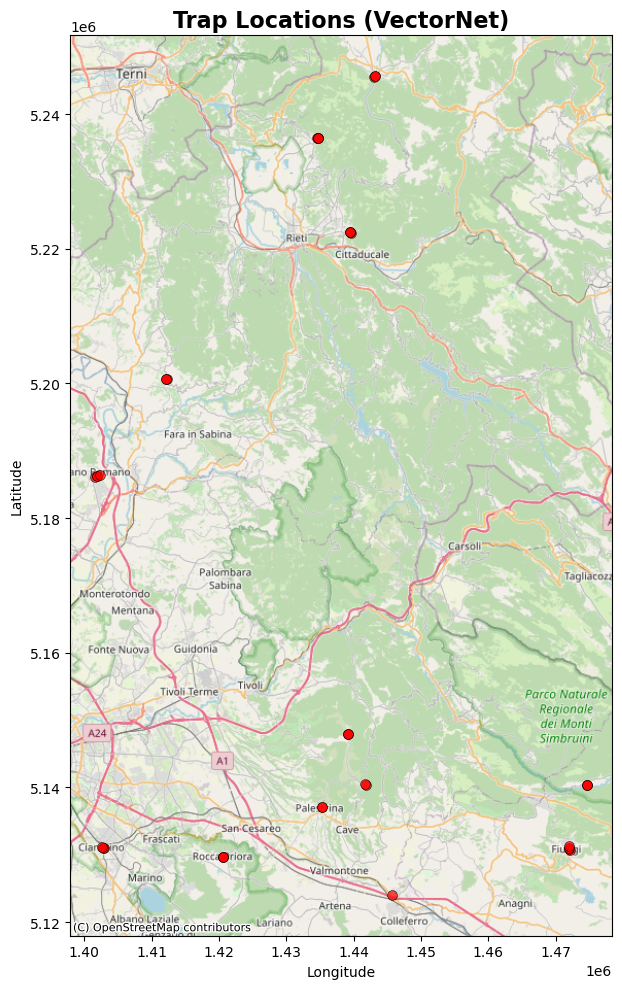

In [10]:
# plot on map the location of the traps on vvectorNet, group by trap_id
import geopandas as gpd
import contextily as ctx
from matplotlib import pyplot as plt

# Assuming data_egg_vectorNet has a 'trap_id' column and coordinates in 'latitude' and 'longitude'
gdf_vectorNet = gpd.GeoDataFrame(
    data_egg_vectorNet,
    geometry=gpd.points_from_xy(data_egg_vectorNet['lon'], data_egg_vectorNet['lat']),
    crs="EPSG:4326"  # Assuming WGS84 coordinate system
)
# set geometry
gdf_vectorNet.set_geometry('geometry', inplace=True)
# Group by 'trap_id' and calculate the mean coordinates
gdf_vectorNet_grouped = gdf_vectorNet.groupby('id_trap').agg({'geometry': 'first'}).reset_index()
# set geometry again
gdf_vectorNet_grouped = gpd.GeoDataFrame(gdf_vectorNet_grouped, geometry='geometry', crs="EPSG:4326")

# Convert to Web Mercator for better basemap visualization
gdf_vectorNet_grouped_mercator = gdf_vectorNet_grouped.to_crs(epsg=3857)

# Plotting the grouped GeoDataFrame with basemap
fig, ax = plt.subplots(figsize=(12, 10))
gdf_vectorNet_grouped_mercator.plot(
    ax=ax,
    marker='o',
    color='red',
    markersize=50,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# Add basemap
ctx.add_basemap(ax, crs=gdf_vectorNet_grouped_mercator.crs, source=ctx.providers.OpenStreetMap.Mapnik)

# Set title and labels
ax.set_title('Trap Locations (VectorNet)', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

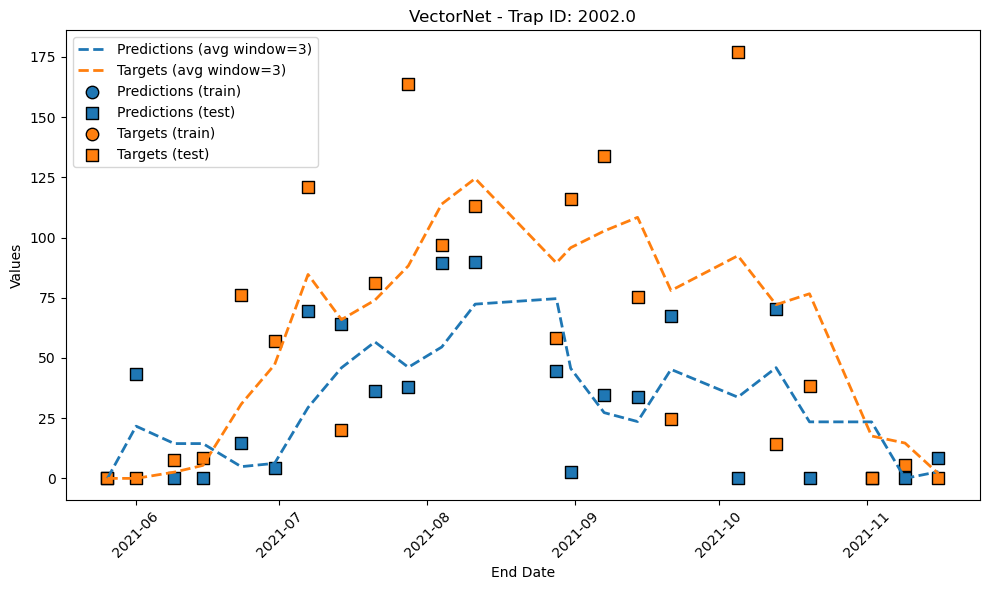

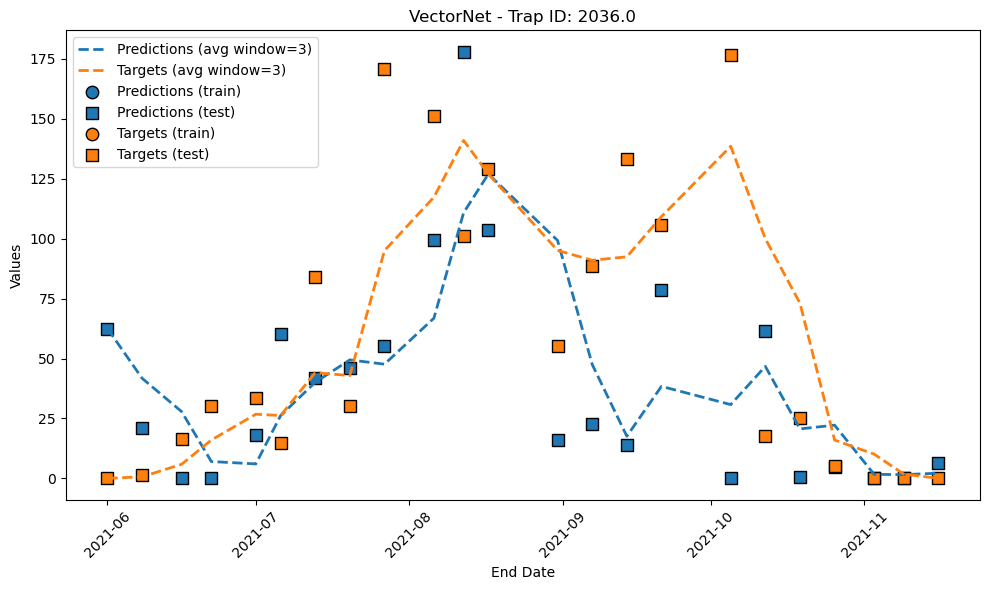

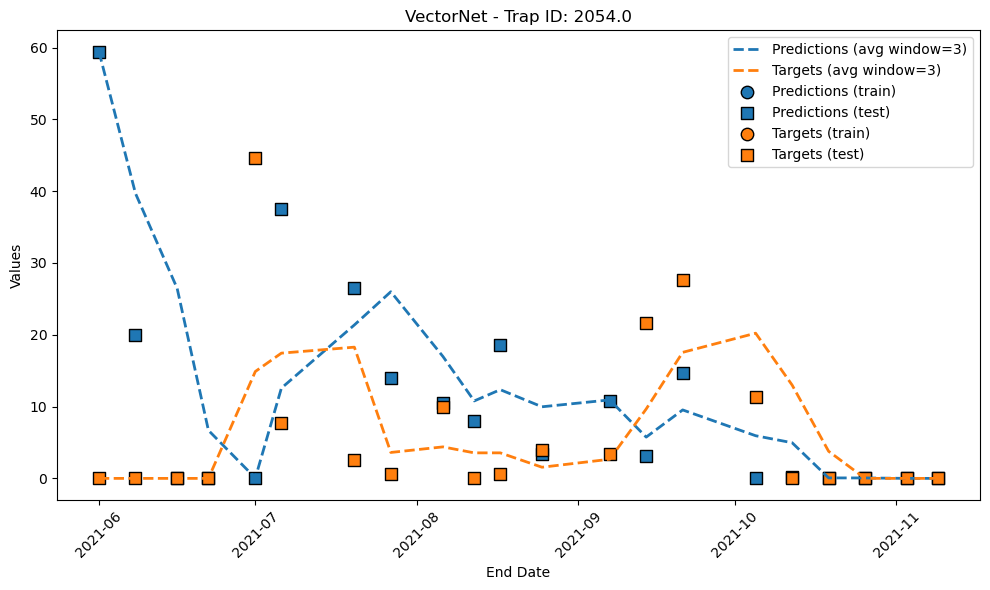

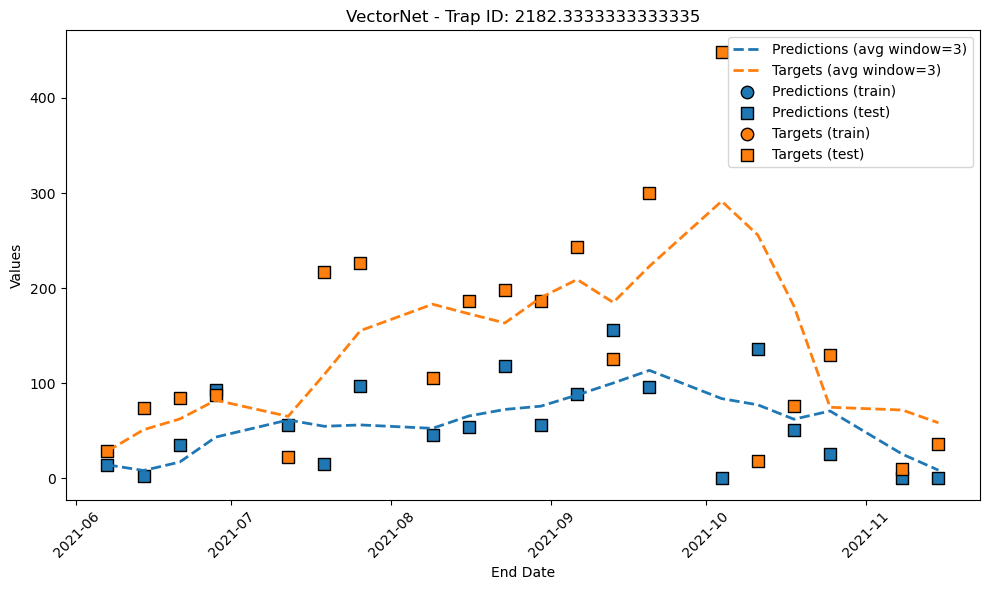

In [11]:
# Define the window size for rolling average
window_size = 3  # Adjust as needed
# the first 5 most populated id_traps with data are
id_trap_plot_vectorNet = data_egg_vectorNet.groupby("id_trap").size().sort_values(ascending=False)
data_egg_vectorNet["split"] = "test"

for id_trap in id_trap_plot_vectorNet.index[0:4]:
    trap_data = data_egg_vectorNet[data_egg_vectorNet["id_trap"] == id_trap].sort_values(by="end_date")

    plt.figure(figsize=(10, 6))

    # Original lines
    #plt.plot(trap_data["end_date"], trap_data["predictions"], label="Predictions", color='tab:blue', alpha=0.5)
    #plt.plot(trap_data["end_date"], trap_data["target_data"], label="Targets", color='tab:orange', alpha=0.5)

    # Rolling averages
    trap_data["predictions_avg"] = trap_data["predictions"].rolling(window=window_size, min_periods=1).mean()
    trap_data["targets_avg"] = trap_data["target_data"].rolling(window=window_size, min_periods=1).mean()

    plt.plot(trap_data["end_date"], trap_data["predictions_avg"], label=f"Predictions (avg window={window_size})", color='tab:blue', linestyle='--', linewidth=2)
    plt.plot(trap_data["end_date"], trap_data["targets_avg"], label=f"Targets (avg window={window_size})", color='tab:orange', linestyle='--', linewidth=2)

    # Plot points
    train_mask = trap_data["split"] == "train"
    test_mask = trap_data["split"] == "test"

    plt.scatter(
        trap_data.loc[train_mask, "end_date"], trap_data.loc[train_mask, "predictions"],
        marker="o", color='tab:blue', label="Predictions (train)", edgecolor='k', s=80
    )
    plt.scatter(
        trap_data.loc[test_mask, "end_date"], trap_data.loc[test_mask, "predictions"],
        marker="s", color='tab:blue', label="Predictions (test)", edgecolor='k', s=80
    )

    plt.scatter(
        trap_data.loc[train_mask, "end_date"], trap_data.loc[train_mask, "target_data"],
        marker="o", color='tab:orange', label="Targets (train)", edgecolor='k', s=80
    )
    plt.scatter(
        trap_data.loc[test_mask, "end_date"], trap_data.loc[test_mask, "target_data"],
        marker="s", color='tab:orange', label="Targets (test)", edgecolor='k', s=80
    )

    plt.xlabel("End Date")
    plt.ylabel("Values")
    plt.title(f"VectorNet - Trap ID: {id_trap}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [12]:
# Get trap counts and merge with country information
trap_counts = data_egg.groupby('id_trap').size().reset_index(name='num_entries')

# Get country information for each trap (take first occurrence since traps are in same location)
trap_countries = data_egg.groupby('id_trap')['country'].first().reset_index()

# Count entries where weeklyRates > 10 for each trap
high_rates_counts = data_egg[data_egg['weeklyRates'] > 10].groupby('id_trap').size().reset_index(name='high_rates_entries')

# Merge the counts with country information
trap_summary = trap_counts.merge(trap_countries, on='id_trap')
trap_summary = trap_summary.merge(high_rates_counts, on='id_trap', how='left')

# Fill NaN values with 0 for traps with no high rates
trap_summary['high_rates_entries'] = trap_summary['high_rates_entries'].fillna(0).astype(int)

# Sort by number of entries (descending)
trap_summary = trap_summary.sort_values('num_entries', ascending=False)

# Display all traps with their entries, high rates entries, and country
print(f"Total number of traps: {len(trap_summary)}")
print("\nTrap ID | Entries | High Rates (>10) | Country")
print("-" * 50)
for _, row in trap_summary.iterrows():
    print(f"{int(row['id_trap']):7d} | {int(row['num_entries']):7d} | {int(row['high_rates_entries']):15d} | {row['country']}")


Total number of traps: 387

Trap ID | Entries | High Rates (>10) | Country
--------------------------------------------------
    360 |      33 |              20 | Albania
    361 |      33 |              19 | Albania
    363 |      33 |              21 | Albania
    365 |      33 |              19 | Albania
    291 |      32 |              13 | Albania
    293 |      32 |              13 | Albania
    295 |      32 |              15 | Albania
    362 |      32 |              18 | Albania
    292 |      31 |              14 | Albania
    290 |      31 |               9 | Albania
    282 |      27 |              13 | Albania
    278 |      27 |              14 | Albania
    279 |      27 |              15 | Albania
   1260 |      26 |               0 | Austria
    280 |      26 |              17 | Albania
    281 |      26 |               9 | Albania
   1238 |      26 |               0 | Austria
   1244 |      26 |               0 | Austria
   1544 |      25 |               0 | Austria


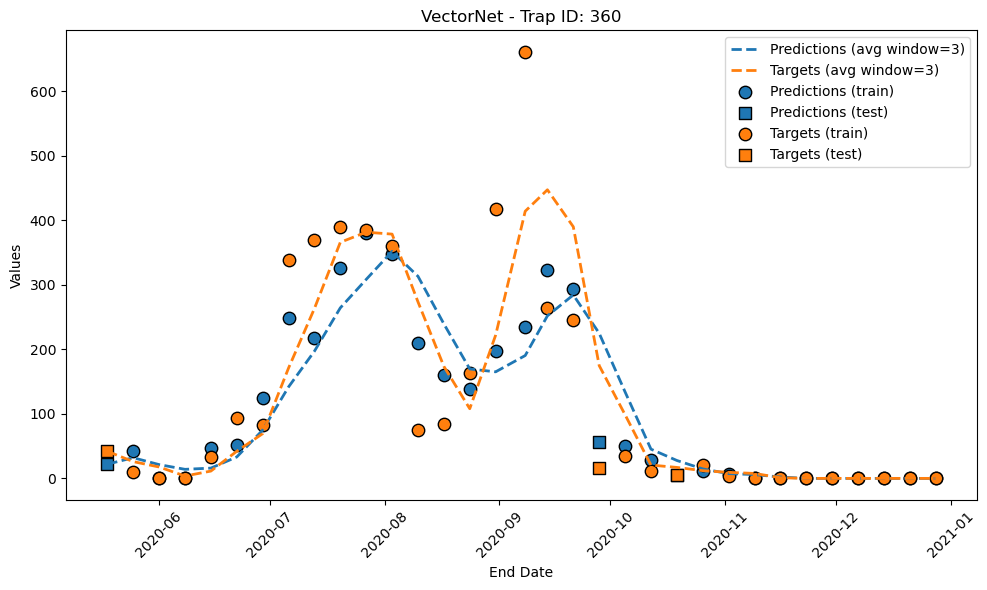

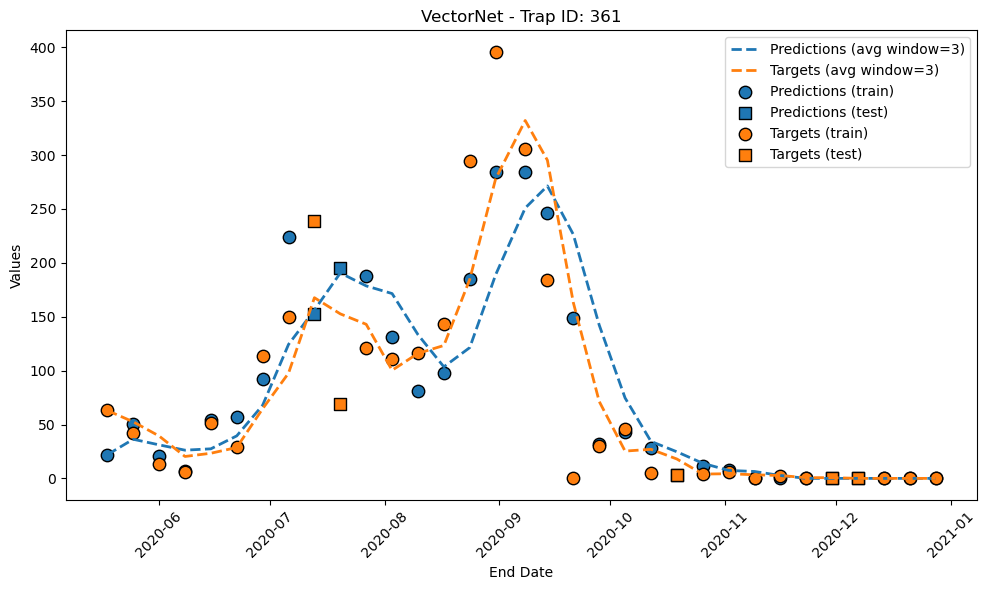

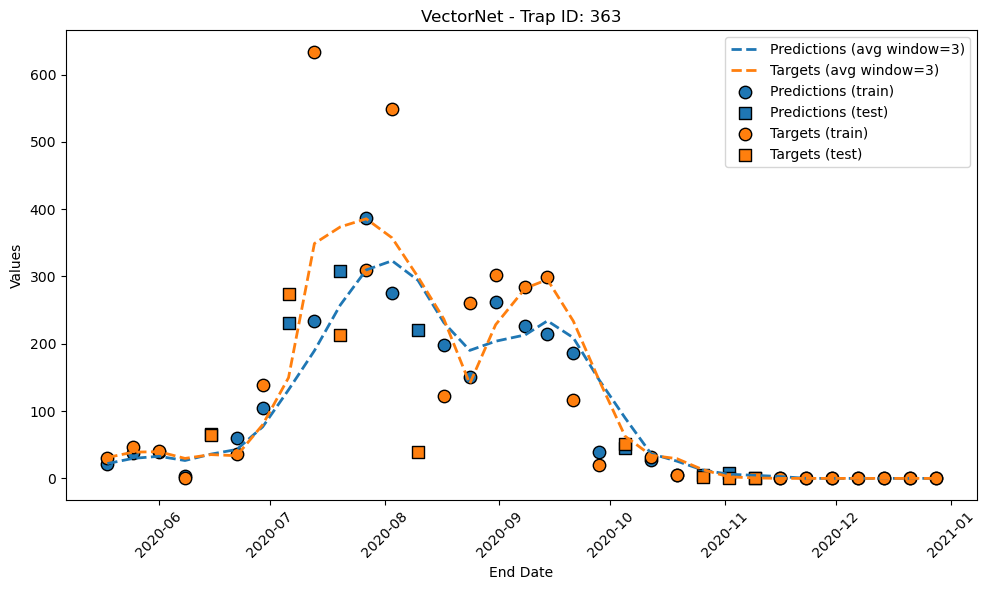

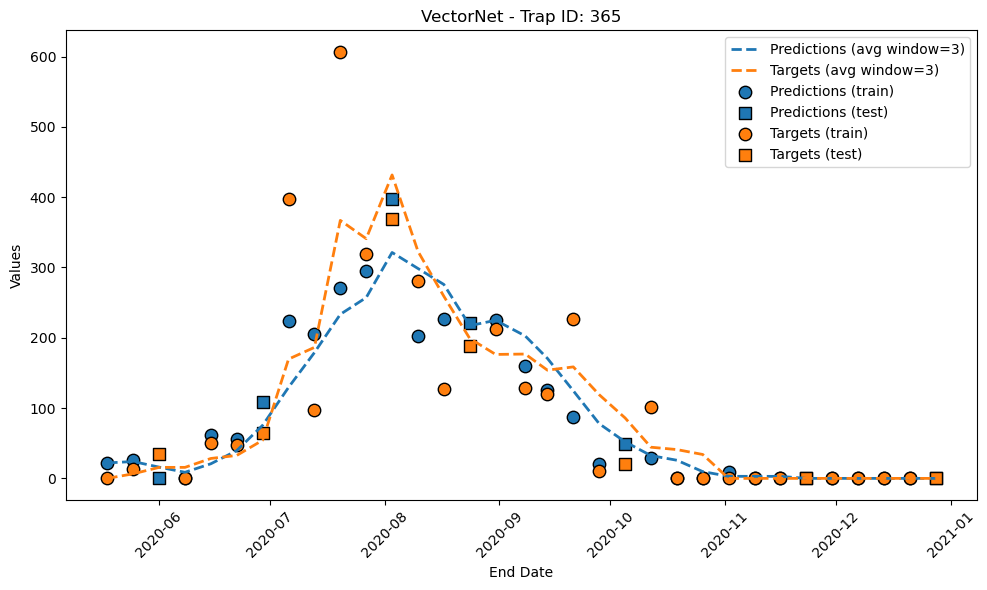

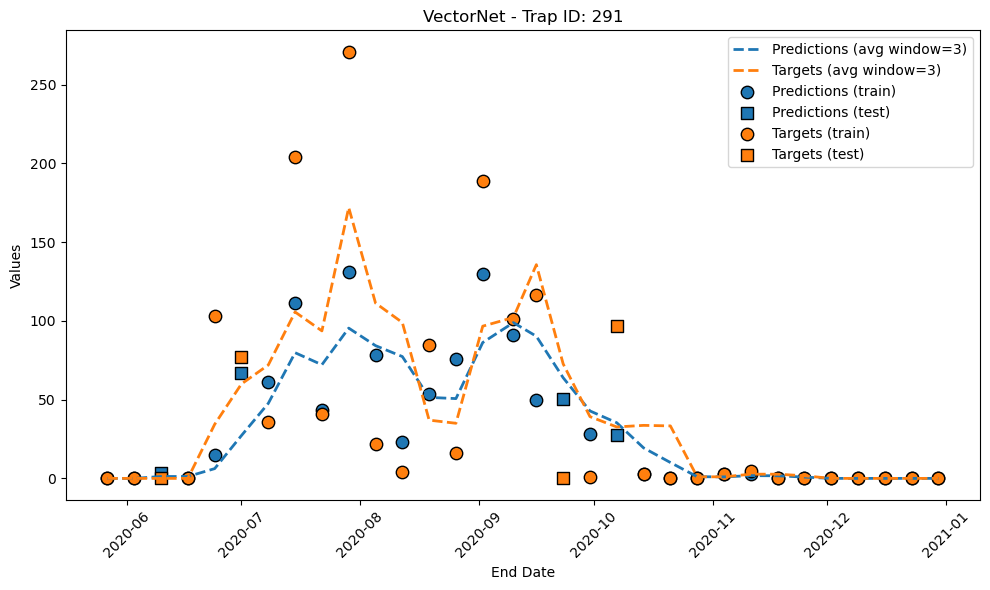

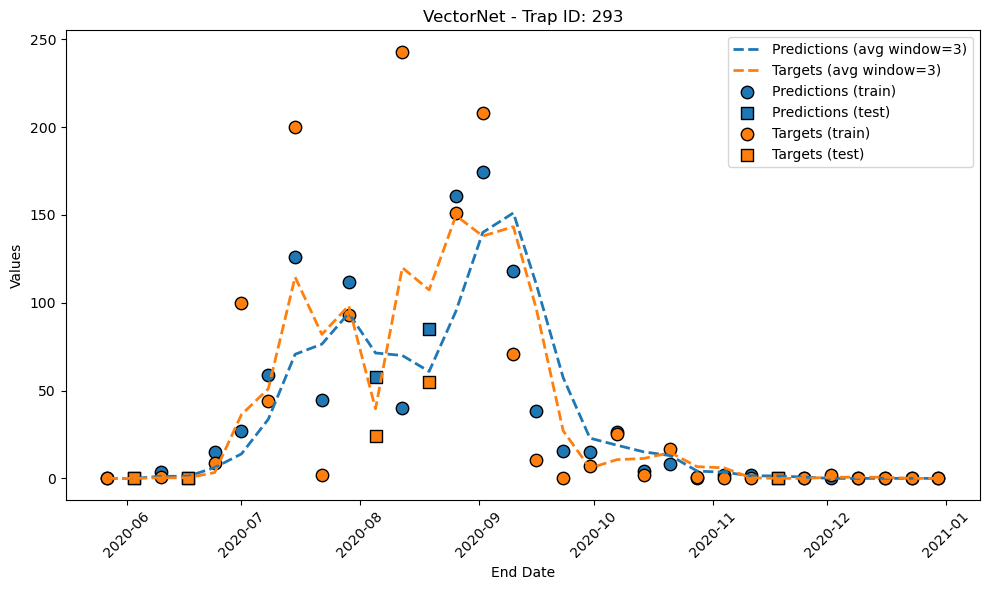

In [13]:
# Define the window size for rolling average
window_size = 3  # Adjust as needed
# the first 5 most populated id_traps with data are
id_trap_plot = data_egg.groupby("id_trap").size().sort_values(ascending=False)
#data_egg_vectorNet["split"] = "test"

for id_trap in id_trap_plot.index[0:6]:
    trap_data = data_egg[data_egg["id_trap"] == id_trap].sort_values(by="end_date")
    #trap_data["split"] = "test"
    plt.figure(figsize=(10, 6))

    # Original lines
    #plt.plot(trap_data["end_date"], trap_data["predictions"], label="Predictions", color='tab:blue', alpha=0.5)
    #plt.plot(trap_data["end_date"], trap_data["target_data"], label="Targets", color='tab:orange', alpha=0.5)

    # Rolling averages
    trap_data["predictions_avg"] = trap_data["predictions"].rolling(window=window_size, min_periods=1).mean()
    trap_data["targets_avg"] = trap_data["target_data"].rolling(window=window_size, min_periods=1).mean()

    plt.plot(trap_data["end_date"], trap_data["predictions_avg"], label=f"Predictions (avg window={window_size})", color='tab:blue', linestyle='--', linewidth=2)
    plt.plot(trap_data["end_date"], trap_data["targets_avg"], label=f"Targets (avg window={window_size})", color='tab:orange', linestyle='--', linewidth=2)

    # Plot points
    train_mask = trap_data["split"] == "train"
    test_mask = trap_data["split"] == "test"

    plt.scatter(
        trap_data.loc[train_mask, "end_date"], trap_data.loc[train_mask, "predictions"],
        marker="o", color='tab:blue', label="Predictions (train)", edgecolor='k', s=80
    )
    plt.scatter(
        trap_data.loc[test_mask, "end_date"], trap_data.loc[test_mask, "predictions"],
        marker="s", color='tab:blue', label="Predictions (test)", edgecolor='k', s=80
    )

    plt.scatter(
        trap_data.loc[train_mask, "end_date"], trap_data.loc[train_mask, "target_data"],
        marker="o", color='tab:orange', label="Targets (train)", edgecolor='k', s=80
    )
    
    plt.scatter(
        trap_data.loc[test_mask, "end_date"], trap_data.loc[test_mask, "target_data"],
        marker="s", color='tab:orange', label="Targets (test)", edgecolor='k', s=80
    )

    plt.xlabel("End Date")
    plt.ylabel("Values")
    plt.title(f"VectorNet - Trap ID: {id_trap}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [14]:
id_traps_vn = [2002, 2036, 2054]

id_traps = [363, 362, 279, 448, 456, 473, 376, 406, 221]
id_traps = [363, 362, 279, 448, 456, 376, 221, 1244, 1260]
#id_traps = [363, 365, 360, 361, 362, 295]

data_egg_most_populatet = data_egg[data_egg["id_trap"].isin(id_traps)].copy()
data_egg_most_populatet["dataset"] = "AIMSurv"
data_egg_vectorNet_most_populatet = data_egg_vectorNet[data_egg_vectorNet["id_trap"].isin(id_traps_vn)].copy()
data_egg_most_populatet = data_egg_most_populatet.rename(columns={"decimalLatitude": "lat", "decimalLongitude": "lon"})
data_egg_vectorNet_most_populatet["dataset"] = "VectorNet"
data_egg_vectorNet_most_populatet["country"] = "italy"
#merge the two dataframes
data_egg_most_populatet = pd.concat([data_egg_most_populatet, data_egg_vectorNet_most_populatet], ignore_index=True)
# plot on maps the traps, with coloro distinguish the dataset
gdf_most_populatet = gpd.GeoDataFrame(
    data_egg_most_populatet,
    geometry=gpd.points_from_xy(data_egg_most_populatet['lon'], data_egg_most_populatet['lat']),
    crs="EPSG:4326"  # Assuming WGS84 coordinate system
)
# set geometry
gdf_most_populatet.set_geometry('geometry', inplace=True)
# Group by 'trap_id' and calculate the mean coordinates
gdf_most_populatet_grouped = gdf_most_populatet.groupby('id_trap').agg({'geometry': 'first', 'dataset': 'first', 'country': "first"}).reset_index()
# set geometry again
gdf_most_populatet_grouped = gpd.GeoDataFrame(gdf_most_populatet_grouped, geometry='geometry', crs="EPSG:4326")
# Convert to Web Mercator for better basemap visualization
gdf_most_populatet_grouped_mercator = gdf_most_populatet_grouped.to_crs(epsg=3857)
# Plotting the grouped GeoDataFrame with basemap


# MAIN PLOT

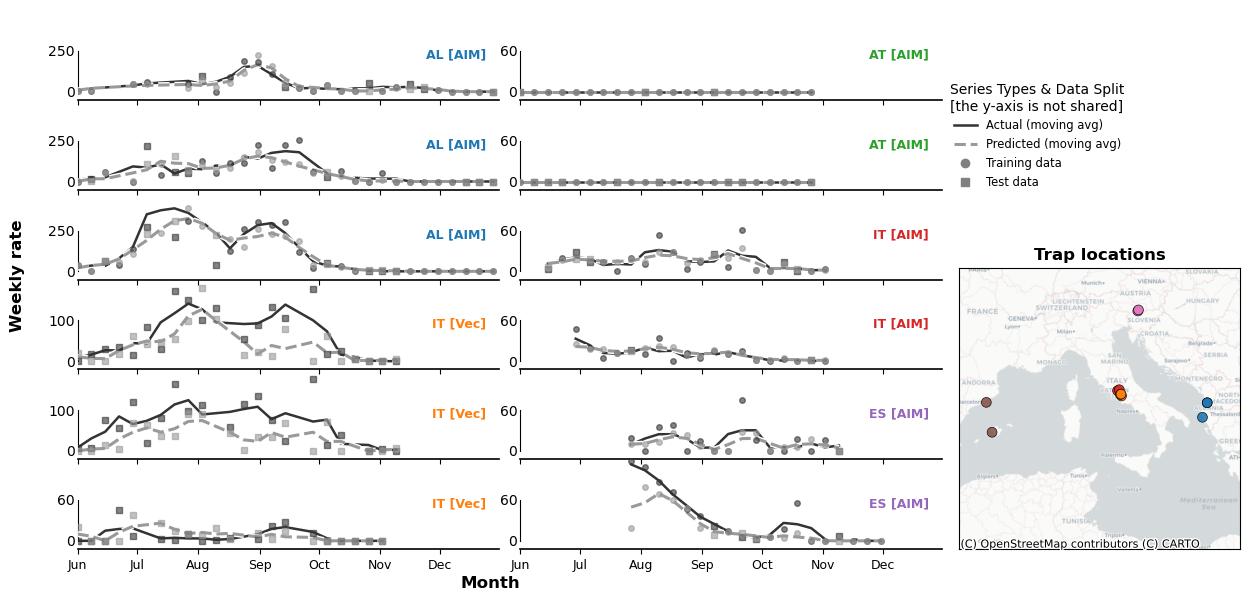

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.transforms import blended_transform_factory as blend
import matplotlib.patheffects as pe
import pycountry

# --- CONFIG --------------------------------------------------------------------
START, END = pd.Timestamp("2020-06-01"), pd.Timestamp("2020-12-31")
month_ticks  = pd.date_range("2020-06-01", "2020-12-01", freq="MS")
month_labels = [d.strftime("%b") for d in month_ticks]

# --- HELPERS -------------------------------------------------------------------

curve_styles = {
    "actual": {
        "color": "#333333",   # dark grey
        "linestyle": "-", 
        "linewidth": 1.8,
        "fill": False,         # fill below the line
        "fill_alpha": 0.2
    },
    "predicted": {
        #"color": "#1f77b4",   # blue
        # light grey
        "color": "#999999",
        "linestyle": "--",
        "linewidth": 2.2,
        "fill": False
    }
}

# Marker styles for train/test data
marker_styles = {
    "train": {"marker": "o", "markersize": 4},
    "test": {"marker": "s", "markersize": 4}  # square for test
}

color_map = {}

def get_country_abbreviation(country_name):
    try:
        # Get the official alpha_2 country code
        return pycountry.countries.lookup(country_name).alpha_2
    except LookupError:
        # Fallback to the first two letters if the country is not found
        return country_name[:2]

def get_color(country, dataset):
    country_abbr = get_country_abbreviation(country)
    key = (country_abbr, dataset[:3])
    if key not in color_map:
        # assign a new color if not already present
        # e.g. cycling through Matplotlib default colors
        color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
        color_map[key] = color_cycle[len(color_map) % len(color_cycle)]
    return color_map[key]

def series_to_fake_2020(df, col, window=3):
    wk = (df["end_date"].dt.isocalendar().week.astype(int)
          .rename("week").to_frame().join(df[[col, "split"]])
          .groupby("week").agg({col: 'mean', 'split': lambda x: list(x)}).sort_index())
    idx = pd.to_datetime([pd.Timestamp.fromisocalendar(2020, int(w), 1) for w in wk.index])
    wk.index = idx
    wk = wk[(wk.index >= START) & (wk.index <= END)]
    
    # Extract the series and split info
    wk_series = wk[col]
    wk_split = wk['split']
    
    return (wk_series.rolling(window=window, center=True, min_periods=1).mean(), 
            wk_series, 
            wk_split)

def mini_y_axis(ax):
    ymin, ymax = ax.get_ylim()
    ymax2 = int(ymax / 2)
    ax.yaxis.set_major_locator(mticker.FixedLocator([0, ymax2]))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    ax.tick_params(axis='y', length=0, pad=2)
    ax.spines['left'].set_visible(False)
    # short vertical line at x=0 (axes coords), from 0 to ymax2 (data coords)
    ax.plot([0.0, 0.0], [0, ymax2], transform=blend(ax.transAxes, ax.transData),
            color='black', lw=0.8, clip_on=False)

def plot_points_by_split(ax, index, values, split_info, color, alpha=0.6, zorder=4):
    """Plot points with different markers based on train/test split"""
    for i, (date, value, splits) in enumerate(zip(index, values, split_info)):
        # Determine the predominant split for this point
        # If it's a list, take the most common one
        if isinstance(splits, list):
            if len(splits) > 0:
                split_type = max(set(splits), key=splits.count)  # most common
            else:
                split_type = "train"  # default
        else:
            split_type = splits
        
        # Get marker style based on split
        marker_style = marker_styles.get(split_type, marker_styles["train"])
        
        ax.plot(date, value,
                marker=marker_style["marker"],
                linestyle="",
                color=color,
                markersize=marker_style["markersize"],
                alpha=alpha,
                zorder=zorder)

def plot_trap(ax, df, trap_id, y_max):
    targ, all_targ, split_targ = series_to_fake_2020(df, "target_data", window=3)
    pred, all_pred, split_pred = series_to_fake_2020(df, "predictions", window=3)

    # --- Actual curve ---
    s = curve_styles["actual"]
    if s["fill"]:
        ax.fill_between(targ.index, targ.values, 0,
                        color=s["color"], alpha=s["fill_alpha"], zorder=1)
    line1, = ax.plot(targ.index, targ.values,
                     color=s["color"], linestyle=s["linestyle"],
                     lw=s["linewidth"], label="Actual (moving avg)", zorder=2)
    
    # Plot actual points with train/test markers
    plot_points_by_split(ax, all_targ.index, all_targ.values, split_targ.values,
                        s["color"], alpha=0.6, zorder=4)
    
    # Add white contour
    line1.set_path_effects([
        pe.Stroke(linewidth=s["linewidth"]+2, foreground='white'),
        pe.Normal()
    ])

    # --- Predicted curve ---
    s = curve_styles["predicted"]
    if s["fill"]:
        ax.fill_between(pred.index, pred.values, 0,
                        color=s["color"], alpha=s["fill_alpha"], zorder=1)
    line2, = ax.plot(pred.index, pred.values,
                     color=s["color"], linestyle=s["linestyle"],
                     lw=s["linewidth"], label="Predicted (moving avg)", zorder=3)
    
    # Plot predicted points with train/test markers
    plot_points_by_split(ax, all_pred.index, all_pred.values, split_pred.values,
                        s["color"], alpha=0.6, zorder=5)

    # Add white contour
    line2.set_path_effects([
        pe.Stroke(linewidth=s["linewidth"]+2, foreground='white'),
        pe.Normal()
    ])
    # cosmetics
    ax.set_xlim(START, END)
    ax.set_ylim(-0.1*y_max, y_max)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.patch.set_alpha(0.0)  # transparent subplot background

    # inline label (right-center)
    country = (df["country"].iloc[0].capitalize() if "country" in df.columns and len(df) else "Unk")
    dataset = (df["dataset"].iloc[0] if "dataset" in df.columns and len(df) else "?")
    country = (df["country"].iloc[0].capitalize() if "country" in df.columns and len(df) else "Unk")
    dataset = (df["dataset"].iloc[0] if "dataset" in df.columns and len(df) else "?")

    col = get_color(country, dataset)

    ax.text(0.97, 0.5, f"{get_country_abbreviation(country)} [{dataset[:3]}]",
            transform=ax.transAxes,
            ha='right', va='center',
            fontsize=9, fontweight='bold',
            color=col)

    # minimal y axis
    mini_y_axis(ax)

# --- DATA SELECTION ------------------------------------------------------------
aim_ids = (data_egg_most_populatet
           .loc[data_egg_most_populatet["dataset"]=="AIMSurv", ["id_trap","country"]]
           .drop_duplicates().sort_values("country")["id_trap"].values[:9])
vec_ids = (data_egg_most_populatet
           .loc[data_egg_most_populatet["dataset"]=="VectorNet", ["id_trap","country"]]
           .drop_duplicates().sort_values("country")["id_trap"].values[:3])

# --- FIGURE --------------------------------------------------------------------
fig = plt.figure(figsize=(15, 7))
# 1 row, 2 cols
outer = fig.add_gridspec(1, 2, width_ratios=[4, 1.3], wspace=0.03)

# Left: time series grid
left = outer[0].subgridspec(6, 2, hspace=0.0, wspace=0.05)
axes = np.array([[fig.add_subplot(left[r, c]) for c in range(2)] for r in range(6)])

# Right: map, bottom-aligned and with fixed aspect
ax_map = fig.add_subplot(outer[1])
ax_map.set_aspect('auto')      # remove fixed aspect constraint
ax_map.set_box_aspect(None)    # (undo any previous set_box_aspect)
ax_map.set_anchor('S')         # still bottom-align

# PLOT TIMESERIES ON LEFT PANEL
# draw
mult = -0.10
for ax, tid in zip(axes[0:3, 0], aim_ids[:3]):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=500)
for ax, tid in zip(axes[3:-1, 0], vec_ids):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=200)
ax = axes[-1, 0]
df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==vec_ids[-1]]
plot_trap(ax, df, tid, y_max=120)

for ax, tid in zip(axes[:, 1], aim_ids[3:]):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=120)

# global x ticks only on last row
for ax in axes.ravel():
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
for ax in axes[-1, :]:
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels)
    ax.tick_params(axis='x', labelbottom=True, labelsize=9)

## PLOT MAP ON RIGHT PANEL

# Clean axes
ax_map.set_xticks([]); ax_map.set_yticks([])
ax_map.set_xlabel(''); ax_map.set_ylabel('')

# Europe bounds → Web Mercator
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
min_x, min_y = transformer.transform(-5, 30)   # SW
max_x, max_y = transformer.transform(40, 60)   # NE
ax_map.set_xlim(min_x, max_x); ax_map.set_ylim(min_y, max_y)

gdf = gdf_most_populatet_grouped_mercator.copy()

# Get bounds of your points in Web Mercator
xmin, ymin, xmax, ymax = gdf.total_bounds

# Add padding (in meters; tweak factor=0.1 → 10% margin)
pad_x = (xmax - xmin) * 0.1
pad_y = (ymax - ymin) * 0.01

ax_map.set_xlim(xmin - pad_x, xmax + pad_x)
ax_map.set_ylim(ymin - pad_y, ymax + pad_y)

gdf["country2"] = gdf["country"].astype(str).str.capitalize().str[:2]
gdf["dataset3"] = gdf["dataset"].astype(str).str[:3]
gdf["color"]    = [get_color(c, d) for c, d in zip(gdf["country2"], gdf["dataset3"])]

# ensure Web Mercator for points + basemap
if gdf.crs is None or gdf.crs.to_epsg() != 3857:
    gdf = gdf.to_crs(3857)

# basemap first (fixed zoom; keep your limits)
import contextily as ctx
ctx.add_basemap(ax_map, crs=gdf.crs,
                source=ctx.providers.CartoDB.Positron,
                zoom=5, reset_extent=False)

# PLOT POINTS using your exact colors (don't use column=)
gdf.plot(ax=ax_map,
         color=gdf["color"],           # <- use the hex colors directly
         markersize=50, alpha=0.9,
         edgecolor="black", linewidth=0.5,
         legend=False)

# optional: custom legend matching (country2, dataset3) -> color
from matplotlib.lines import Line2D
'''
keys = list(dict.fromkeys(zip(gdf["country"].map(get_country_abbreviation), gdf["dataset3"])))  # preserve order
handles = [Line2D([0],[0], marker='o', linestyle='None',
                  markerfacecolor=get_color(c,d), markeredgecolor='black',
                  markersize=6, label=f"{c} [{d}]")
           for c,d in keys]
ax_map.legend(
    handles=handles,
    title="Country [Dataset]",
    loc="lower center",           # anchor relative to bbox_to_anchor
    bbox_to_anchor=(0.5, 1.02),   # center, slightly above axis
    fontsize="small",
    frameon=False,
    ncol=2                        # optional: arrange entries in 2 columns
)
'''


ax_map.set_title('Trap locations', fontsize=12, fontweight='bold')


# bold axis labels (apply only to the left panel)
fig.supxlabel("Month", fontsize=12, fontweight="bold", x=0.4, y=0.05)  # shift left
fig.supylabel("Weekly rate", fontsize=12, fontweight="bold", x=0.08)

# Create comprehensive legend including train/test markers
from matplotlib.lines import Line2D

# Get original legend handles and labels (for line types)
handles, labels = axes[0,0].get_legend_handles_labels()

# Add marker legend entries
train_handle = Line2D([0], [0], marker='o', color='gray', linestyle='None',
                     markersize=6, label='Training data')
test_handle = Line2D([0], [0], marker='s', color='gray', linestyle='None',
                    markersize=6, label='Test data')

# Combine all handles and labels
all_handles = handles + [train_handle, test_handle]
all_labels = labels + ['Training data', 'Test data']

# shared legend (place between left plots and right map)
fig.legend(all_handles, all_labels,
           loc="center left",
           bbox_to_anchor=(0.7, 0.7),   # adjust anchor closer to map
           frameon=False,
           #fontsize="Large",
           title="Series Types & Data Split\n[the y-axis is not shared]",
           # the title is centered over two lines
           fontsize="small"
           )

#plt.subplots_adjust(wspace=0.05, hspace=0.0)
plt.savefig("./most_populated_traps_time_series.pdf", bbox_inches="tight")
plt.show()

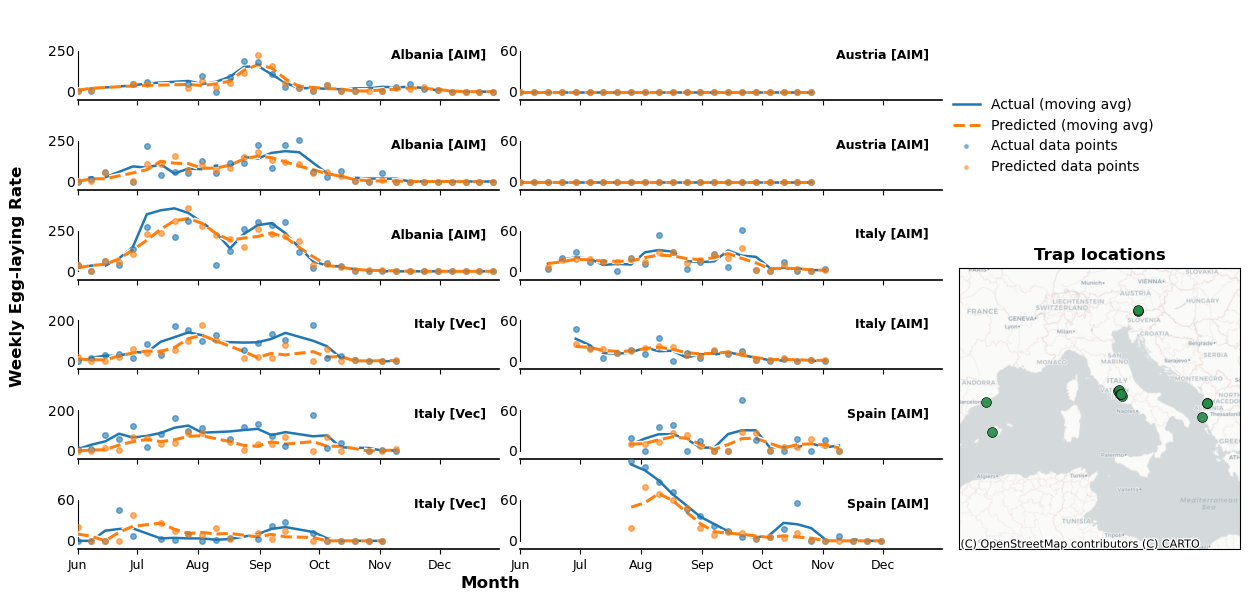

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.transforms import blended_transform_factory as blend
import matplotlib.patheffects as pe
import pycountry

# --- CONFIG --------------------------------------------------------------------
START, END = pd.Timestamp("2020-06-01"), pd.Timestamp("2020-12-31")
month_ticks  = pd.date_range("2020-06-01", "2020-12-01", freq="MS")
month_labels = [d.strftime("%b") for d in month_ticks]

# --- HELPERS -------------------------------------------------------------------

curve_styles = {
    "actual": {
        "color": "#1f77b4",   # matplotlib blue
        "linestyle": "-", 
        "linewidth": 1.8,
        "fill": False,         # fill below the line
        "fill_alpha": 0.2
    },
    "predicted": {
        "color": "#ff7f0e",   # matplotlib orange
        "linestyle": "--",
        "linewidth": 2.2,
        "fill": False
    }
}

# Marker styles for train/test data - removed differentiation
marker_styles = {
    "default": {"marker": "o", "markersize": 4}
}

def get_country_abbreviation(country_name):
    try:
        # Get the official alpha_2 country code
        return country_name
        #return pycountry.countries.lookup(country_name).alpha_2
    except LookupError:
        # Fallback to the first two letters if the country is not found
        return country_name[:2]

def series_to_fake_2020(df, col, window=3):
    wk = (df["end_date"].dt.isocalendar().week.astype(int)
          .rename("week").to_frame().join(df[[col, "split"]])
          .groupby("week").agg({col: 'mean', 'split': lambda x: list(x)}).sort_index())
    idx = pd.to_datetime([pd.Timestamp.fromisocalendar(2020, int(w), 1) for w in wk.index])
    wk.index = idx
    wk = wk[(wk.index >= START) & (wk.index <= END)]
    
    # Extract the series and split info
    wk_series = wk[col]
    wk_split = wk['split']
    
    return (wk_series.rolling(window=window, center=True, min_periods=1).mean(), 
            wk_series, 
            wk_split)

def mini_y_axis(ax):
    ymin, ymax = ax.get_ylim()
    ymax2 = int(ymax / 2)
    ax.yaxis.set_major_locator(mticker.FixedLocator([0, ymax2]))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    ax.tick_params(axis='y', length=0, pad=2)
    ax.spines['left'].set_visible(False)
    # short vertical line at x=0 (axes coords), from 0 to ymax2 (data coords)
    ax.plot([0.0, 0.0], [0, ymax2], transform=blend(ax.transAxes, ax.transData),
            color='black', lw=0.8, clip_on=False)

def plot_points_by_split(ax, index, values, split_info, color, alpha=0.6, zorder=4):
    """Plot points with the same marker regardless of split"""
    for i, (date, value, splits) in enumerate(zip(index, values, split_info)):
        # Use default marker style for all points
        marker_style = marker_styles["default"]
        
        ax.plot(date, value,
                marker=marker_style["marker"],
                linestyle="",
                color=color,
                markersize=marker_style["markersize"],
                alpha=alpha,
                zorder=zorder)

def plot_trap(ax, df, trap_id, y_max):
    targ, all_targ, split_targ = series_to_fake_2020(df, "target_data", window=3)
    pred, all_pred, split_pred = series_to_fake_2020(df, "predictions", window=3)

    # --- Actual curve ---
    s = curve_styles["actual"]
    if s["fill"]:
        ax.fill_between(targ.index, targ.values, 0,
                        color=s["color"], alpha=s["fill_alpha"], zorder=1)
    line1, = ax.plot(targ.index, targ.values,
                     color=s["color"], linestyle=s["linestyle"],
                     lw=s["linewidth"], label="Actual (moving avg)", zorder=2)
    
    # Plot actual points with default markers
    plot_points_by_split(ax, all_targ.index, all_targ.values, split_targ.values,
                        s["color"], alpha=0.6, zorder=4)
    
    # Add white contour
    line1.set_path_effects([
        pe.Stroke(linewidth=s["linewidth"]+2, foreground='white'),
        pe.Normal()
    ])

    # --- Predicted curve ---
    s = curve_styles["predicted"]
    if s["fill"]:
        ax.fill_between(pred.index, pred.values, 0,
                        color=s["color"], alpha=s["fill_alpha"], zorder=1)
    line2, = ax.plot(pred.index, pred.values,
                     color=s["color"], linestyle=s["linestyle"],
                     lw=s["linewidth"], label="Predicted (moving avg)", zorder=3)
    
    # Plot predicted points with default markers
    plot_points_by_split(ax, all_pred.index, all_pred.values, split_pred.values,
                        s["color"], alpha=0.6, zorder=5)

    # Add white contour
    line2.set_path_effects([
        pe.Stroke(linewidth=s["linewidth"]+2, foreground='white'),
        pe.Normal()
    ])
    # cosmetics
    ax.set_xlim(START, END)
    ax.set_ylim(-0.1*y_max, y_max)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.patch.set_alpha(0.0)  # transparent subplot background

    # inline label (right-center) - use standard black color
    country = (df["country"].iloc[0].capitalize() if "country" in df.columns and len(df) else "Unk")
    dataset = (df["dataset"].iloc[0] if "dataset" in df.columns and len(df) else "?")

    ax.text(0.97, 0.5, f"{get_country_abbreviation(country)} [{dataset[:3]}]",
            transform=ax.transAxes,
            ha='right', va='center',
            fontsize=9, fontweight='bold',
            color='black')  # Use standard black color

    # minimal y axis
    mini_y_axis(ax)

# --- DATA SELECTION ------------------------------------------------------------
aim_ids = (data_egg_most_populatet
           .loc[data_egg_most_populatet["dataset"]=="AIMSurv", ["id_trap","country"]]
           .drop_duplicates().sort_values("country")["id_trap"].values[:9])
vec_ids = (data_egg_most_populatet
           .loc[data_egg_most_populatet["dataset"]=="VectorNet", ["id_trap","country"]]
           .drop_duplicates().sort_values("country")["id_trap"].values[:3])

# --- FIGURE --------------------------------------------------------------------
fig = plt.figure(figsize=(15, 7))
# 1 row, 2 cols
outer = fig.add_gridspec(1, 2, width_ratios=[4, 1.3], wspace=0.03)

# Left: time series grid
left = outer[0].subgridspec(6, 2, hspace=0.0, wspace=0.05)
axes = np.array([[fig.add_subplot(left[r, c]) for c in range(2)] for r in range(6)])

# Right: map, bottom-aligned and with fixed aspect
ax_map = fig.add_subplot(outer[1])
ax_map.set_aspect('auto')      # remove fixed aspect constraint
ax_map.set_box_aspect(None)    # (undo any previous set_box_aspect)
ax_map.set_anchor('S')         # still bottom-align

# PLOT TIMESERIES ON LEFT PANEL
# draw
mult = -0.10
for ax, tid in zip(axes[0:3, 0], aim_ids[:3]):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=500)
for ax, tid in zip(axes[3:-1, 0], vec_ids):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=400)
ax = axes[-1, 0]
df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==vec_ids[-1]]
plot_trap(ax, df, tid, y_max=120)

for ax, tid in zip(axes[:, 1], aim_ids[3:]):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=120)

# global x ticks only on last row
for ax in axes.ravel():
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
for ax in axes[-1, :]:
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels)
    ax.tick_params(axis='x', labelbottom=True, labelsize=9)

## PLOT MAP ON RIGHT PANEL

# Clean axes
ax_map.set_xticks([]); ax_map.set_yticks([])
ax_map.set_xlabel(''); ax_map.set_ylabel('')

# Europe bounds → Web Mercator
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
min_x, min_y = transformer.transform(-5, 30)   # SW
max_x, max_y = transformer.transform(40, 60)   # NE
ax_map.set_xlim(min_x, max_x); ax_map.set_ylim(min_y, max_y)

gdf = gdf_most_populatet_grouped_mercator.copy()

# Get bounds of your points in Web Mercator
xmin, ymin, xmax, ymax = gdf.total_bounds

# Add padding (in meters; tweak factor=0.1 → 10% margin)
pad_x = (xmax - xmin) * 0.1
pad_y = (ymax - ymin) * 0.01

ax_map.set_xlim(xmin - pad_x, xmax + pad_x)
ax_map.set_ylim(ymin - pad_y, ymax + pad_y)

# ensure Web Mercator for points + basemap
if gdf.crs is None or gdf.crs.to_epsg() != 3857:
    gdf = gdf.to_crs(3857)

# basemap first (fixed zoom; keep your limits)
import contextily as ctx
ctx.add_basemap(ax_map, crs=gdf.crs,
                source=ctx.providers.CartoDB.Positron,
                zoom=5, reset_extent=False)

# PLOT POINTS using standard blue color
gdf.plot(ax=ax_map,
         color='#238b45',              # Standard matplotlib blue
         markersize=50, alpha=0.9,
         edgecolor="black", linewidth=0.5,
         legend=False)

ax_map.set_title('Trap locations', fontsize=12, fontweight='bold')

# bold axis labels (apply only to the left panel)
fig.supxlabel("Month", fontsize=12, fontweight="bold", x=0.4, y=0.05)  # shift left
fig.supylabel("Weekly Egg-laying Rate", fontsize=12, fontweight="bold", x=0.08)

# Create comprehensive legend including marker points
from matplotlib.lines import Line2D

# Get original legend handles and labels (for line types)
handles, labels = axes[0,0].get_legend_handles_labels()

# Add marker legend entries for actual and predicted points
actual_marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', 
                      markersize=4, alpha=0.6, linestyle='', label='Actual (weekly)')
predicted_marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', 
                         markersize=4, alpha=0.6, linestyle='', label='Predicted (weekly)')

# Combine all handles and labels
all_handles = handles + [actual_marker, predicted_marker]
all_labels = labels + ['Actual data points', 'Predicted data points']

# shared legend (place between left plots and right map)
fig.legend(all_handles, all_labels,
           loc="center left",
           bbox_to_anchor=(0.7, 0.7),   # adjust anchor closer to map
           frameon=False,
           #fontsize="Large",
           #title="Series Types\n[the y-axis is not shared]",
           # the title is centered over two lines
           #fontsize="small"
           )

#plt.subplots_adjust(wspace=0.05, hspace=0.0)
plt.savefig("./most_populated_traps_time_series.pdf", bbox_inches="tight")
plt.show()


2020-06-01    1.138854e+01
2020-06-08    1.436858e+01
2020-06-29    3.433727e+01
2020-07-06    4.069282e+01
2020-07-27    4.114533e+01
2020-08-03    5.366818e+01
2020-08-10    2.024327e+01
2020-08-17    4.284863e+01
2020-08-24    1.203276e+02
2020-08-31    2.264717e+02
2020-09-07    1.482473e+02
2020-09-14    4.720176e+01
2020-09-21    2.669144e+01
2020-09-28    1.787430e+01
2020-10-05    4.306077e+01
2020-10-12    6.672564e+00
2020-10-19    3.716954e+00
2020-10-26    9.396879e+00
2020-11-02    6.340205e+00
2020-11-09    2.128683e+01
2020-11-16    1.559010e+01
2020-11-23    4.121112e+01
2020-11-30    5.292064e-26
2020-12-07    3.915604e-33
2020-12-14    1.844734e-30
2020-12-21    0.000000e+00
2020-12-28    0.000000e+00
Name: predictions, dtype: float32
2020-06-01     26.832338
2020-06-08      5.622940
2020-06-15     53.306286
2020-06-29      0.000011
2020-07-06    165.960236
2020-07-13     87.627083
2020-07-20     84.328789
2020-07-27     52.435486
2020-08-03    102.509682
2020-08-10  

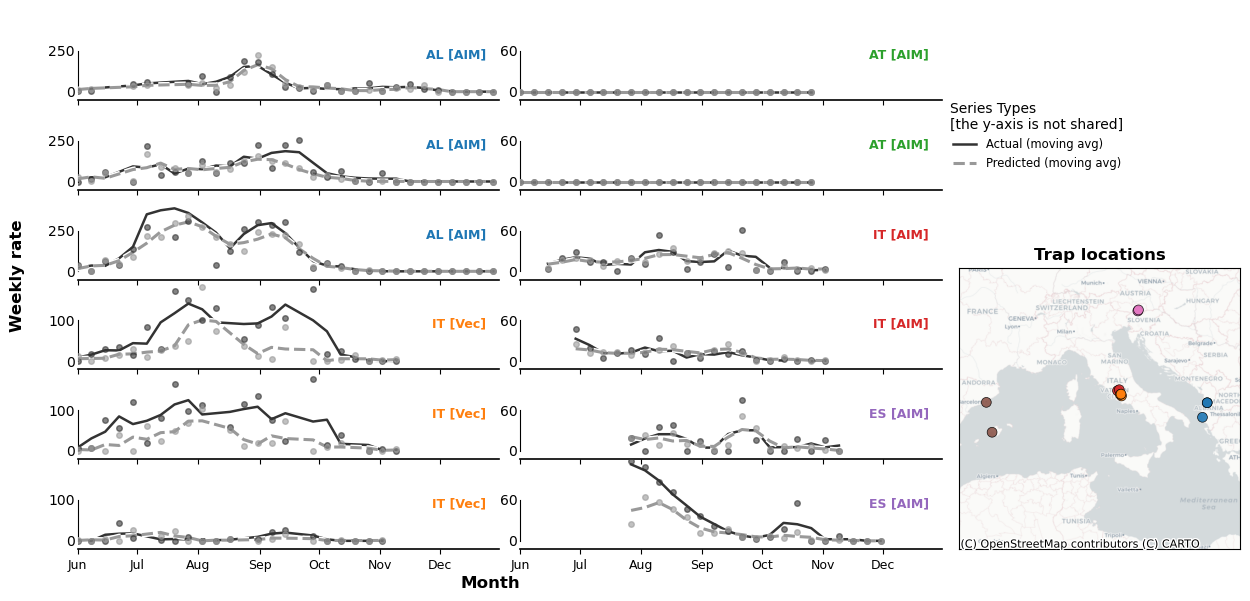

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.transforms import blended_transform_factory as blend
import matplotlib.patheffects as pe
import pycountry

# --- CONFIG --------------------------------------------------------------------
START, END = pd.Timestamp("2020-06-01"), pd.Timestamp("2020-12-31")
month_ticks  = pd.date_range("2020-06-01", "2020-12-01", freq="MS")
month_labels = [d.strftime("%b") for d in month_ticks]

# --- HELPERS -------------------------------------------------------------------

curve_styles = {
    "actual": {
        "color": "#333333",   # dark grey
        "linestyle": "-", 
        "linewidth": 1.8,
        "fill": False,         # fill below the line
        "fill_alpha": 0.2
    },
    "predicted": {
        #"color": "#1f77b4",   # blue
        # light grey
        "color": "#999999",
        "linestyle": "--",
        "linewidth": 2.2,
        "fill": False
    }
}

color_map = {}

def get_country_abbreviation(country_name):
    try:
        # Get the official alpha_2 country code
        return pycountry.countries.lookup(country_name).alpha_2
    except LookupError:
        # Fallback to the first two letters if the country is not found
        return country_name[:2]

def get_color(country, dataset):
    country_abbr = get_country_abbreviation(country)
    key = (country_abbr, dataset[:3])
    if key not in color_map:
        # assign a new color if not already present
        # e.g. cycling through Matplotlib default colors
        color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
        color_map[key] = color_cycle[len(color_map) % len(color_cycle)]
    return color_map[key]

def series_to_fake_2020(df, col, window=3):
    wk = (df["end_date"].dt.isocalendar().week.astype(int)
          .rename("week").to_frame().join(df[[col, "split"]])
          .groupby("week").agg({col: 'mean', 'split': lambda x: list(x)}).sort_index())
    idx = pd.to_datetime([pd.Timestamp.fromisocalendar(2020, int(w), 1) for w in wk.index])
    wk.index = idx
    wk = wk[(wk.index >= START) & (wk.index <= END)]
    
    # Extract the series and split info
    wk_series = wk[col]
    wk_split = wk['split']
    
    return (wk_series.rolling(window=window, center=True, min_periods=1).mean(), 
            wk_series, 
            wk_split)

def mini_y_axis(ax):
    ymin, ymax = ax.get_ylim()
    ymax2 = int(ymax / 2)
    ax.yaxis.set_major_locator(mticker.FixedLocator([0, ymax2]))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    ax.tick_params(axis='y', length=0, pad=2)
    ax.spines['left'].set_visible(False)
    # short vertical line at x=0 (axes coords), from 0 to ymax2 (data coords)
    ax.plot([0.0, 0.0], [0, ymax2], transform=blend(ax.transAxes, ax.transData),
            color='black', lw=0.8, clip_on=False)

def plot_trap(ax, df, trap_id, y_max):
    targ, all_targ, split_targ = series_to_fake_2020(df, "target_data", window=3)
    pred, all_pred, split_pred = series_to_fake_2020(df, "predictions", window=3)

    # --- Actual curve ---
    s = curve_styles["actual"]
    if s["fill"]:
        ax.fill_between(targ.index, targ.values, 0,
                        color=s["color"], alpha=s["fill_alpha"], zorder=1)
    line1, = ax.plot(targ.index, targ.values,
                     color=s["color"], linestyle=s["linestyle"],
                     lw=s["linewidth"], label="Actual (moving avg)", zorder=2)
    point1, = ax.plot(all_targ.index, all_targ.values,
                      marker="o", linestyle="", color=s["color"],
                      markersize=4, alpha=0.6, zorder=4)
    print(all_pred)
    # Add white contour
    line1.set_path_effects([
        pe.Stroke(linewidth=s["linewidth"]+2, foreground='white'),
        pe.Normal()
    ])

    # --- Predicted curve ---
    s = curve_styles["predicted"]
    if s["fill"]:
        ax.fill_between(pred.index, pred.values, 0,
                        color=s["color"], alpha=s["fill_alpha"], zorder=1)
    line2, = ax.plot(pred.index, pred.values,
                     color=s["color"], linestyle=s["linestyle"],
                     lw=s["linewidth"], label="Predicted (moving avg)", zorder=3)
    point2, = ax.plot(all_pred.index, all_pred.values,
                      marker="o", linestyle="", color=s["color"],
                      markersize=4, alpha=0.6, zorder=5)

    # Add white contour
    line2.set_path_effects([
        pe.Stroke(linewidth=s["linewidth"]+2, foreground='white'),
        pe.Normal()
    ])
    # cosmetics
    ax.set_xlim(START, END)
    ax.set_ylim(-0.1*y_max, y_max)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.patch.set_alpha(0.0)  # transparent subplot background

    # inline label (right-center)
    country = (df["country"].iloc[0].capitalize() if "country" in df.columns and len(df) else "Unk")
    dataset = (df["dataset"].iloc[0] if "dataset" in df.columns and len(df) else "?")
    country = (df["country"].iloc[0].capitalize() if "country" in df.columns and len(df) else "Unk")
    dataset = (df["dataset"].iloc[0] if "dataset" in df.columns and len(df) else "?")

    col = get_color(country, dataset)

    ax.text(0.97, 0.5, f"{get_country_abbreviation(country)} [{dataset[:3]}]",
            transform=ax.transAxes,
            ha='right', va='center',
            fontsize=9, fontweight='bold',
            color=col)

    # minimal y axis
    mini_y_axis(ax)

# --- DATA SELECTION ------------------------------------------------------------
aim_ids = (data_egg_most_populatet
           .loc[data_egg_most_populatet["dataset"]=="AIMSurv", ["id_trap","country"]]
           .drop_duplicates().sort_values("country")["id_trap"].values[:9])
vec_ids = (data_egg_most_populatet
           .loc[data_egg_most_populatet["dataset"]=="VectorNet", ["id_trap","country"]]
           .drop_duplicates().sort_values("country")["id_trap"].values[:3])

# --- FIGURE --------------------------------------------------------------------
fig = plt.figure(figsize=(15, 7))
# 1 row, 2 cols
outer = fig.add_gridspec(1, 2, width_ratios=[4, 1.3], wspace=0.03)

# Left: time series grid
left = outer[0].subgridspec(6, 2, hspace=0.0, wspace=0.05)
axes = np.array([[fig.add_subplot(left[r, c]) for c in range(2)] for r in range(6)])

# Right: map, bottom-aligned and with fixed aspect
ax_map = fig.add_subplot(outer[1])
ax_map.set_aspect('auto')      # remove fixed aspect constraint
ax_map.set_box_aspect(None)    # (undo any previous set_box_aspect)
ax_map.set_anchor('S')         # still bottom-align

# PLOT TIMESERIES ON LEFT PANEL
# draw
mult = -0.10
for ax, tid in zip(axes[0:3, 0], aim_ids[:3]):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=500)
for ax, tid in zip(axes[3:, 0], vec_ids):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=200)
for ax, tid in zip(axes[:, 1], aim_ids[3:]):
    df = data_egg_most_populatet.loc[data_egg_most_populatet["id_trap"]==tid]
    plot_trap(ax, df, tid, y_max=120)

# global x ticks only on last row
for ax in axes.ravel():
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
for ax in axes[-1, :]:
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels)
    ax.tick_params(axis='x', labelbottom=True, labelsize=9)

## PLOT MAP ON RIGHT PANEL

# Clean axes
ax_map.set_xticks([]); ax_map.set_yticks([])
ax_map.set_xlabel(''); ax_map.set_ylabel('')

# Europe bounds → Web Mercator
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
min_x, min_y = transformer.transform(-5, 30)   # SW
max_x, max_y = transformer.transform(40, 60)   # NE
ax_map.set_xlim(min_x, max_x); ax_map.set_ylim(min_y, max_y)

gdf = gdf_most_populatet_grouped_mercator.copy()

# Get bounds of your points in Web Mercator
xmin, ymin, xmax, ymax = gdf.total_bounds

# Add padding (in meters; tweak factor=0.1 → 10% margin)
pad_x = (xmax - xmin) * 0.1
pad_y = (ymax - ymin) * 0.01

ax_map.set_xlim(xmin - pad_x, xmax + pad_x)
ax_map.set_ylim(ymin - pad_y, ymax + pad_y)

gdf["country2"] = gdf["country"].astype(str).str.capitalize().str[:2]
gdf["dataset3"] = gdf["dataset"].astype(str).str[:3]
gdf["color"]    = [get_color(c, d) for c, d in zip(gdf["country2"], gdf["dataset3"])]

# ensure Web Mercator for points + basemap
if gdf.crs is None or gdf.crs.to_epsg() != 3857:
    gdf = gdf.to_crs(3857)

# basemap first (fixed zoom; keep your limits)
import contextily as ctx
ctx.add_basemap(ax_map, crs=gdf.crs,
                source=ctx.providers.CartoDB.Positron,
                zoom=5, reset_extent=False)

# PLOT POINTS using your exact colors (don't use column=)
gdf.plot(ax=ax_map,
         color=gdf["color"],           # <- use the hex colors directly
         markersize=50, alpha=0.9,
         edgecolor="black", linewidth=0.5,
         legend=False)

# optional: custom legend matching (country2, dataset3) -> color
from matplotlib.lines import Line2D
'''
keys = list(dict.fromkeys(zip(gdf["country"].map(get_country_abbreviation), gdf["dataset3"])))  # preserve order
handles = [Line2D([0],[0], marker='o', linestyle='None',
                  markerfacecolor=get_color(c,d), markeredgecolor='black',
                  markersize=6, label=f"{c} [{d}]")
           for c,d in keys]
ax_map.legend(
    handles=handles,
    title="Country [Dataset]",
    loc="lower center",           # anchor relative to bbox_to_anchor
    bbox_to_anchor=(0.5, 1.02),   # center, slightly above axis
    fontsize="small",
    frameon=False,
    ncol=2                        # optional: arrange entries in 2 columns
)
'''


ax_map.set_title('Trap locations', fontsize=12, fontweight='bold')


# bold axis labels (apply only to the left panel)
fig.supxlabel("Month", fontsize=12, fontweight="bold", x=0.4, y=0.05)  # shift left
fig.supylabel("Weekly rate", fontsize=12, fontweight="bold", x=0.08)

# shared legend (place between left plots and right map)
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="center left",
           bbox_to_anchor=(0.7, 0.7),   # adjust anchor closer to map
           frameon=False,
           #fontsize="Large",
           title="Series Types\n[the y-axis is not shared]",
           # the title is centered over two lines
           fontsize="small"
           )

#plt.subplots_adjust(wspace=0.05, hspace=0.0)
plt.savefig("./most_populated_traps_time_series.pdf", bbox_inches="tight")
plt.show()
